In [5]:
import numpy as np
import pandas as pd

In [7]:
from google.colab import files

uploaded = files.upload()

Saving crypto_daily.csv to crypto_daily.csv


In [8]:
df=pd.read_csv("crypto_daily.csv")

In [11]:
df.head()

,date,symbol,name,open,high,low,close,adj_close,volume,return_1d,...,btc_n_transactions,btc_active_addresses,btc_est_tx_volume_usd,btc_miner_revenue_usd,btc_tx_fees_usd,btc_circulating_supply,year,month,day_of_week,is_weekend
0,2017-11-09,ADA,Cardano,0.025160,0.035060,0.025006,0.032053,0.032053,18716200,NaN,...,341281.0,727946.0,2.366841e+09,1.667847e+07,2.653879e+06,16673000.0,2017,11,3,0
1,2017-11-10,ADA,Cardano,0.032219,0.033348,0.026451,0.027119,0.027119,6766780,-0.153933,...,271745.0,619944.0,2.022294e+09,1.271307e+07,2.226674e+06,16674500.0,2017,11,4,0
2,2017-11-11,ADA,Cardano,0.026891,0.029659,0.025684,0.027437,0.027437,5532220,0.011726,...,197081.0,459977.0,1.401934e+09,8.785091e+06,2.122955e+06,16675512.5,2017,11,5,1
3,2017-11-12,ADA,Cardano,0.027480,0.027952,0.022591,0.023977,0.023977,7280250,-0.126107,...,183519.0,463412.0,1.946783e+09,9.479345e+06,3.495448e+06,16676500.0,2017,11,6,1
4,2017-11-13,ADA,Cardano,0.024364,0.026300,0.023495,0.025808,0.025808,4419440,0.076365,...,309299.0,694905.0,2.070830e+09,1.620952e+07,4.999532e+06,16678250.0,2017,11,0,0


In [13]:
import matplotlib.pyplot as plt


In [12]:
df.shape

(30570, 52)

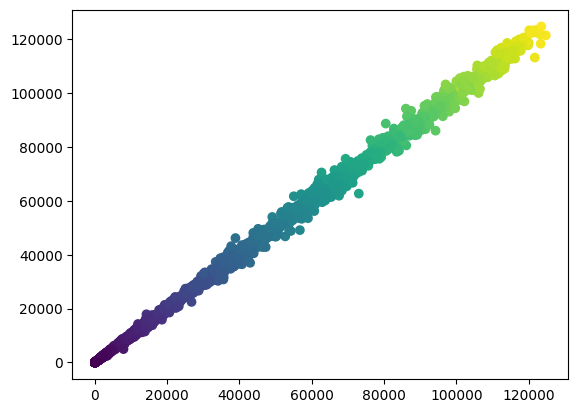

In [17]:
plt.scatter(df['open'],df['close'],c=df['high'])

In [33]:
X = df[['open', 'high', 'volume']]
y = df['close']

In [22]:
print(y)

0        0.025006
1        0.026451
2        0.025684
3        0.022591
4        0.023495
           ...   
30565    1.070939
30566    1.054657
30567    1.089772
30568    1.132768
30569    1.144344
Name: low, Length: 30570, dtype: float64


In [20]:
print(x)

0        0.035060
1        0.033348
2        0.029659
3        0.027952
4        0.026300
           ...   
30565    1.171313
30566    1.112817
30567    1.166491
30568    1.184806
30569    1.175169
Name: high, Length: 30570, dtype: float64


In [23]:
from sklearn.model_selection import train_test_split

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [37]:
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R² Score:", r2_score(y_test, y_pred))

MAE : 78.91944438549046
MSE : 59480.85697133049
RMSE: 243.88697581324527
R² Score: 0.9997576569230894


In [39]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,115444.875000,114777.271951
1,0.507317,15.289240
2,0.348585,19.989196
3,0.386576,11.235264
4,0.781529,18.759680
5,0.634998,6.970779
6,2.129985,27.812322
7,19.497236,35.998842
8,4025.229004,3935.517652
9,7343.895508,7521.920896


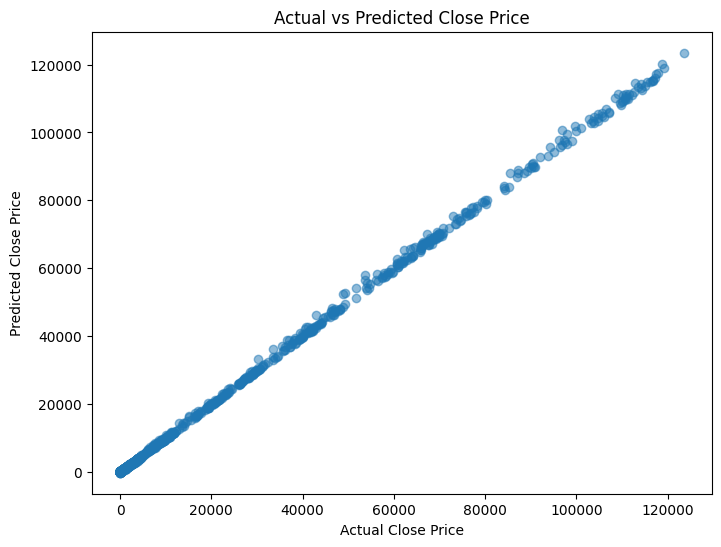

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Close Price")
plt.show()

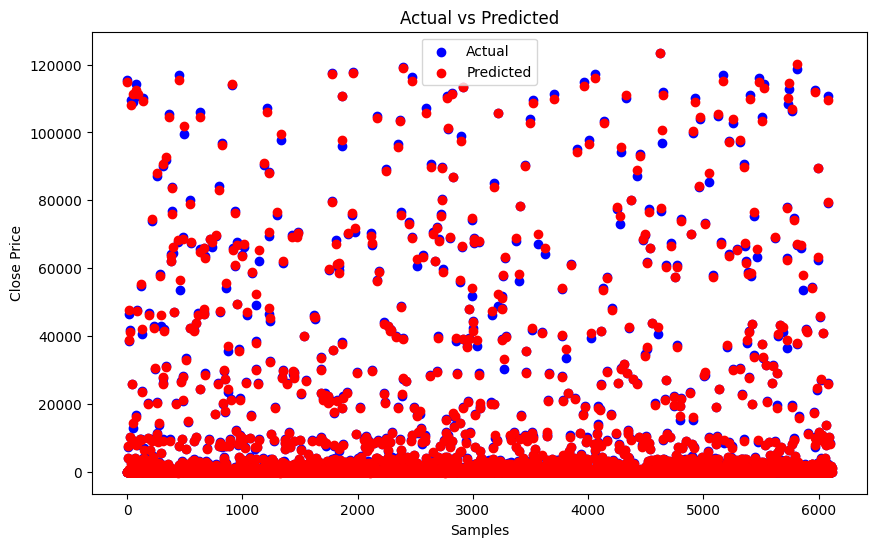

In [41]:
plt.figure(figsize=(10,6))

plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted')

plt.xlabel("Samples")
plt.ylabel("Close Price")
plt.title("Actual vs Predicted")
plt.legend()

plt.show()

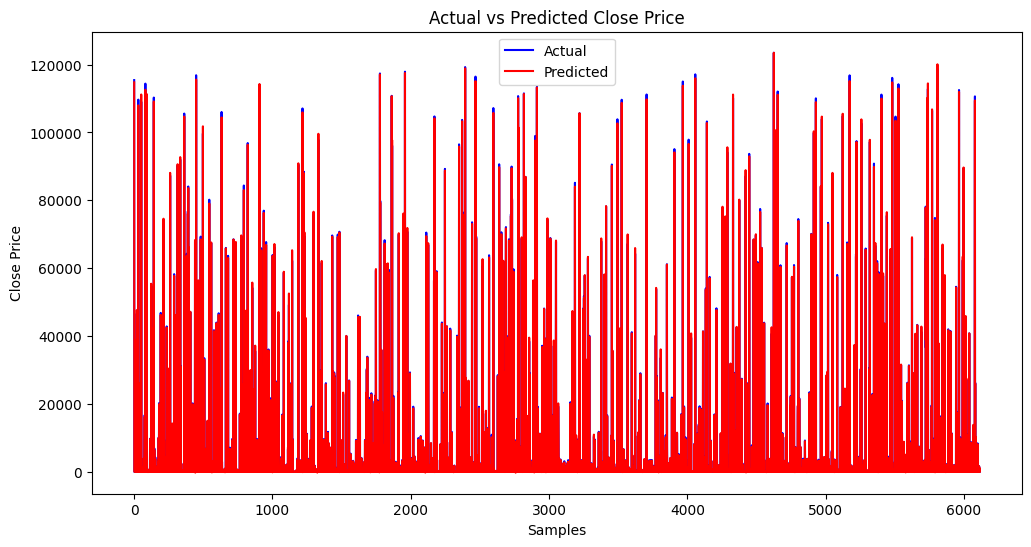

In [42]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, color='blue', label='Actual')
plt.plot(y_pred, color='red', label='Predicted')

plt.xlabel("Samples")
plt.ylabel("Close Price")
plt.title("Actual vs Predicted Close Price")
plt.legend()

plt.show()

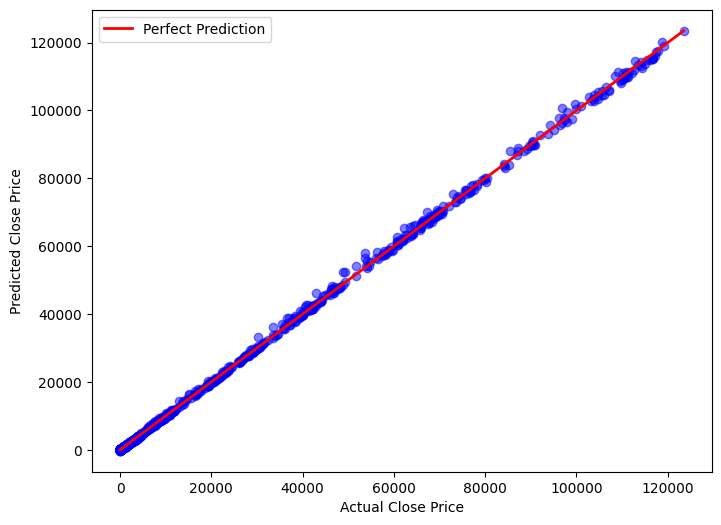

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color='blue', alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.legend()

plt.show()